In [33]:
import pandas as pd
import os
os.environ["OMP_NUM_THREADS"]="1"
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import  warnings
warnings.filterwarnings('ignore')


In [34]:
#1.Data collection
df=pd.read_csv("ifood_df.csv")

In [35]:
#2.data exploration and cleaning
print("initial dataset shape:",df.shape)

initial dataset shape: (2205, 39)


In [36]:
df=df.dropna()

In [37]:
df=df[df['Income']<200000]

In [38]:
#3.descriptive statistics
print("---summary statistics---")
print(df[['Income','Recency','Age','MntTotal']].describe())

---summary statistics---
              Income      Recency          Age     MntTotal
count    2205.000000  2205.000000  2205.000000  2205.000000
mean    51622.094785    49.009070    51.095692   562.764626
std     20713.063826    28.932111    11.705801   575.936911
min      1730.000000     0.000000    24.000000     4.000000
25%     35196.000000    24.000000    43.000000    56.000000
50%     51287.000000    49.000000    50.000000   343.000000
75%     68281.000000    74.000000    61.000000   964.000000
max    113734.000000    99.000000    80.000000  2491.000000


In [39]:
#4.feature selctiion & scaling
features=['Income','Recency','MntTotal','Age']
x=df[features]

In [40]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(x)

In [41]:
#5.customer segmention(k-means)
wcss=[]
for i in range(1,11):
    kmeans=KMeans(n_clusters=i,init='k-means++',random_state=42,n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

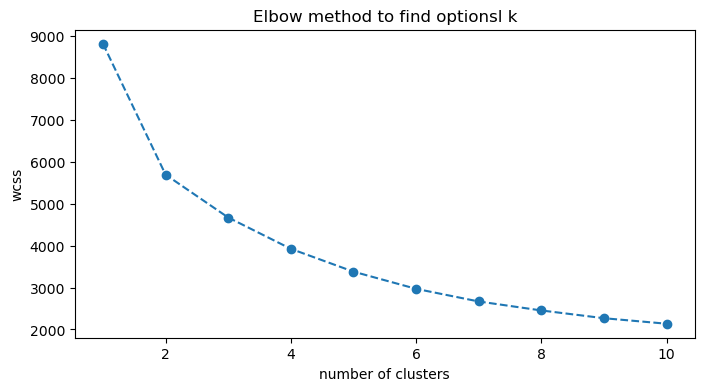

In [43]:
#plot
plt.figure(figsize=(8,4))
plt.plot(range(1,11),wcss,marker='o',linestyle='--')
plt.title('Elbow method to find optionsl k')
plt.xlabel('number of clusters')
plt.ylabel('wcss')
plt.show()

In [44]:
kmeans=KMeans(n_clusters=4,init='k-means++',random_state=42,n_init=10)
df['Segment']=kmeans.fit_predict(x_scaled)

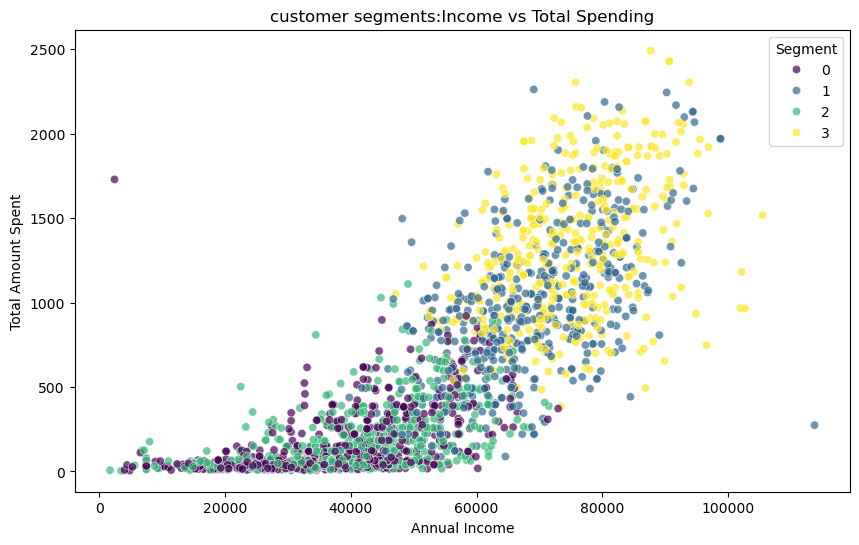

In [45]:
#6.visualization
plt.figure(figsize=(10,6))
sns.scatterplot(data=df,x='Income',y='MntTotal',hue='Segment',palette='viridis',alpha=0.7)
plt.title('customer segments:Income vs Total Spending')
plt.xlabel('Annual Income')
plt.ylabel('Total Amount Spent')
plt.legend(title='Segment')
plt.show()

In [46]:
#7.insights and recommendaations
segment_analysis=df.groupby('Segment')[features].mean()
segment_counts=df['Segment'].value_counts()
segment_analysis['Count']=segment_counts

In [47]:
print("---segment profiiles (avg)--")
print(segment_analysis)

---segment profiiles (avg)--
               Income    Recency     MntTotal        Age  Count
Segment                                                        
0        36332.109907  24.345201   150.541796  46.842105    646
1        68041.465753  42.929550   959.847358  63.743640    511
2        38650.635350  75.818471   173.248408  50.409236    628
3        74558.066667  54.254762  1296.104762  43.276190    420


In [53]:
print("--Business Insights & Recommendations--")
for i in range (len(segment_analysis)):
    row=segment_analysis.loc[i]
    if (row['MntTotal'] > df['MntTotal'].mean() and 
        row['Income'] > df['Income'].mean()):
        print(f"segmnet {i}(vIPs):High income,high spenders.Action:Exclusive loyalty programs and premium offers.")
    elif (row['Income']<df['Income'].mean() and 
        row['MntTotal']< df['MntTotal'].mean()):
        print(f"segmnet {i} (Budget): Lower income,lower spending.Action:Focus on discounts,deals,and value-based marketing.")
    elif row['Recency']>df['Recency'].mean():
        print(f"segment {i}(At Risk):Haven't purchased recently.Action:Re-engagement emails and time-limited discount coupons.")
    else:
        print(f"segment {i} (standard): Average customer.Aciton: Standard newsletters and regular product updates.")

--Business Insights & Recommendations--
segmnet 0 (Budget): Lower income,lower spending.Action:Focus on discounts,deals,and value-based marketing.
segmnet 1(vIPs):High income,high spenders.Action:Exclusive loyalty programs and premium offers.
segmnet 2 (Budget): Lower income,lower spending.Action:Focus on discounts,deals,and value-based marketing.
segmnet 3(vIPs):High income,high spenders.Action:Exclusive loyalty programs and premium offers.
